# Manchester Rent Analysis

## Introduction

This project explores private rent patterns in Manchester between January 2016 and January 2026 using three related datasets:

1. `Mcr_AnnualChangeInRents.csv` – annual percentage change in private rents over time across selected areas  
2. `Mcr_ChangeInAverageRentsByBedroom Number.csv` – annual percentage change by bedroom category  
3. `Mcr_AverageRentMcrComparedWithNW.csv` – average rent comparison between Manchester and wider benchmarks  

The notebook is organised as one small end-to-end exploratory data analysis project. The first dataset is the main time-series dataset, while the other two datasets are used as supporting evidence to add context about bedroom type differences and average rent levels.

A small wording note: most of the analysis is about **annual percentage change**, not monthly rent prices themselves. The average-rent dataset is used separately when discussing rent levels.

## Research Questions

This project aims to answer the following questions:

1. How has annual rent growth changed over time in Manchester?
2. How does Manchester compare with North West, England, and the United Kingdom?
3. Do rent changes differ by bedroom number?
4. How does Manchester's average rent level compare with wider benchmarks?

## Datasets

The three datasets are related, but they are not all at the same level of detail:

- **Main dataset:** area by month (`area_name × date`)
- **Bedroom dataset:** bedroom category snapshot
- **Average rent dataset:** area-level snapshot

For that reason, the project keeps them as **three cleaned DataFrames** rather than forcing them into one merged table.

In [19]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: set a cleaner visual style for plots
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Save charts so they can be shown directly in the GitHub README
os.makedirs("figures", exist_ok=True)

def get_path(filename):
    """Return a working relative path.

    This checks both the project root and the /data folder, so the notebook
    can still run after being uploaded to GitHub.
    """
    candidates = [
        filename,
        os.path.join("data", filename),
        os.path.join("..", "data", filename),
    ]
    for path in candidates:
        if os.path.exists(path):
            return path
    raise FileNotFoundError(f"Could not find {filename}")

## 1. Data Loading and Raw Inspection

In [2]:
file_path_1 = get_path("Mcr_AnnualChangeInRents.csv")
file_path_2 = get_path("Mcr_ChangeInAverageRentsByBedroom Number.csv")
file_path_3 = get_path("Mcr_AverageRentMcrComparedWithNW.csv")

# skiprows=2 removes the title/subtitle rows above the real tabular data
df_raw = pd.read_csv(file_path_1, skiprows=2)
df_bedroom_raw = pd.read_csv(file_path_2, skiprows=2)
df_level_raw = pd.read_csv(file_path_3, skiprows=2)

In [3]:
print("=== MAIN RAW DATA ===")
df_raw.info()

print("\n=== MAIN RAW HEAD ===")
print(df_raw.head())

print("\n=== MAIN RAW COLUMNS ===")
print(df_raw.columns.tolist()[:10], "...")

print("\n=== BEDROOM RAW HEAD ===")
print(df_bedroom_raw.head())

print("\n=== LEVEL RAW HEAD ===")
print(df_level_raw.head())

=== MAIN RAW DATA ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Columns: 122 entries, Area name to Jan 2026
dtypes: float64(121), object(1)
memory usage: 4.9+ KB

=== MAIN RAW HEAD ===
                                           Area name  Jan 2016  Feb 2016  \
0                                         Manchester       2.1       1.4   
1                                         North West       1.6       1.6   
2                                            England       3.5       3.5   
3                                     United Kingdom       3.3       3.3   
4  Source: Price Index of Private Rents from the ...       NaN       NaN   

   Mar 2016  Apr 2016  May 2016  Jun 2016  Jul 2016  Aug 2016  Sep 2016  ...  \
0       1.0       0.8       0.7       0.8       0.9       1.0       0.8  ...   
1       1.6       1.8       1.8       2.1       2.1       2.2       2.1  ...   
2       3.6       3.5       3.3       3.5       3.7       3.6       3.5  ...   
3       3.4 

The raw inspection shows that the main dataset is in **wide format**: each month appears as a separate column. That structure is not ideal for plotting with seaborn or for time-series analysis, so it needs to be reshaped into **long format**.

## 2. Data Cleaning and Validation

In [4]:
# -----------------------------
# 2.1 Clean the main time-series dataset
# -----------------------------

# Clean column names: remove quotation marks and extra spaces
df_raw.columns = df_raw.columns.str.strip().str.replace('"', '', regex=False)

# Clean text values in the area column
df_raw["Area name"] = (
    df_raw["Area name"]
    .astype(str)
    .str.strip()
    .str.replace('"', '', regex=False)
)

# Rename to snake_case for easier coding
df_raw = df_raw.rename(columns={"Area name": "area_name"})

print("=== AREA NAME COUNTS BEFORE FILTERING ===")
print(df_raw["area_name"].value_counts())

=== AREA NAME COUNTS BEFORE FILTERING ===
area_name
Manchester                                                                      1
North West                                                                      1
England                                                                         1
United Kingdom                                                                  1
Source: Price Index of Private Rents from the Office for National Statistics    1
Name: count, dtype: int64


In [5]:
# Keep only the four areas needed for comparison
areas = ["Manchester", "North West", "England", "United Kingdom"]

# .isin(areas) returns True/False for each row.
# Using it inside df_raw[...] keeps only rows where area_name is in the list.
df_subset = df_raw[df_raw["area_name"].isin(areas)].copy()

print("=== FILTERED AREAS ===")
print(df_subset["area_name"].value_counts())

=== FILTERED AREAS ===
area_name
Manchester        1
North West        1
England           1
United Kingdom    1
Name: count, dtype: int64


In [6]:
# Reshape from wide to long format.
# id_vars stays as the identifier column.
# All month columns are folded into two new columns: date and annual_change.
df = df_subset.melt(
    id_vars="area_name",
    var_name="date",
    value_name="annual_change"
)

# Convert data types
df["date"] = pd.to_datetime(df["date"], format="%b %Y")
df["annual_change"] = pd.to_numeric(df["annual_change"], errors="coerce")

# Sort and reset the row index so the DataFrame is tidy and easier to read
df = df.sort_values(["area_name", "date"]).reset_index(drop=True)

print("=== CLEANED MAIN DATASET INFO ===")
df.info()

print("\n=== CLEANED MAIN DATASET HEAD ===")
print(df.head())

=== CLEANED MAIN DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 484 entries, 0 to 483
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   area_name      484 non-null    object        
 1   date           484 non-null    datetime64[ns]
 2   annual_change  484 non-null    float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 11.5+ KB

=== CLEANED MAIN DATASET HEAD ===
  area_name       date  annual_change
0   England 2016-01-01            3.5
1   England 2016-02-01            3.5
2   England 2016-03-01            3.6
3   England 2016-04-01            3.5
4   England 2016-05-01            3.3


In [7]:
# Validation checks
print("=== MISSING VALUES ===")
print(df.isna().sum())

print("\n=== DUPLICATES ON area_name + date ===")
print(df.duplicated(subset=["area_name", "date"]).sum())

print("\n=== DATE RANGE ===")
print("from", df["date"].min().date(), "to", df["date"].max().date())

print("\n=== RECORD COUNT BY AREA ===")
print(df.groupby("area_name")["date"].count())

print("\n=== MONTH COVERAGE CHECK ===")
# The count check above is useful, but it does not prove that every month is present.
# This quick check compares the number of unique months in each area with the expected
# number of months between the first and last date.
expected_months = len(pd.period_range(df["date"].min(), df["date"].max(), freq="M"))
month_counts = df.assign(month=df["date"].dt.to_period("M")).groupby("area_name")["month"].nunique()
print("Expected months:", expected_months)
print(month_counts)
print("All areas have the expected number of months:", (month_counts == expected_months).all())

print("\n=== SUMMARY STATISTICS FOR annual_change ===")
print(df["annual_change"].describe().round(2))

print("\n=== POSSIBLE UNUSUAL annual_change VALUES (>20 or <-10) ===")
# These thresholds are a simple sanity check rather than a formal outlier rule.
print(df[(df["annual_change"] > 20) | (df["annual_change"] < -10)])

=== MISSING VALUES ===
area_name        0
date             0
annual_change    0
dtype: int64

=== DUPLICATES ON area_name + date ===
0

=== DATE RANGE ===
from 2016-01-01 to 2026-01-01

=== RECORD COUNT BY AREA ===
area_name
England           121
Manchester        121
North West        121
United Kingdom    121
Name: date, dtype: int64

=== MONTH COVERAGE CHECK ===
Expected months: 121
area_name
England           121
Manchester        121
North West        121
United Kingdom    121
Name: month, dtype: int64
All areas have the expected number of months: True

=== SUMMARY STATISTICS FOR annual_change ===
count    484.00
mean       4.32
std        3.03
min        0.40
25%        1.80
50%        3.30
75%        6.90
max       12.80
Name: annual_change, dtype: float64

=== POSSIBLE UNUSUAL annual_change VALUES (>20 or <-10) ===
Empty DataFrame
Columns: [area_name, date, annual_change]
Index: []


In [8]:
# -----------------------------
# 2.2 Clean the bedroom snapshot dataset
# -----------------------------
df_bedroom = df_bedroom_raw.copy()

df_bedroom.columns = df_bedroom.columns.str.strip().str.replace('"', '', regex=False)
df_bedroom["Area name"] = df_bedroom["Area name"].astype(str).str.strip()

df_bedroom = df_bedroom.rename(
    columns={
        "Area name": "bedroom_type",
        "value": "annual_change"
    }
)

df_bedroom["annual_change"] = pd.to_numeric(df_bedroom["annual_change"], errors="coerce")

# Drop non-data rows such as Source lines
df_bedroom = df_bedroom.dropna(subset=["annual_change"]).reset_index(drop=True)

print("=== CLEANED BEDROOM DATA ===")
print(df_bedroom)

=== CLEANED BEDROOM DATA ===
            bedroom_type  annual_change
0            One bedroom            3.4
1           Two bedrooms            3.1
2         Three bedrooms            3.2
3  Four or more bedrooms            2.3


In [9]:
# -----------------------------
# 2.3 Clean the average-rent snapshot dataset
# -----------------------------
df_level = df_level_raw.copy()

df_level.columns = df_level.columns.str.strip().str.replace('"', '', regex=False)
df_level["Area name"] = df_level["Area name"].astype(str).str.strip()

df_level = df_level.rename(
    columns={
        "Area name": "area_name",
        "value": "average_rent"
    }
)

df_level["average_rent"] = pd.to_numeric(df_level["average_rent"], errors="coerce")

# Drop note/source rows
df_level = df_level.dropna(subset=["average_rent"]).reset_index(drop=True)

print("=== CLEANED AVERAGE RENT DATA ===")
print(df_level)

=== CLEANED AVERAGE RENT DATA ===
        area_name  average_rent
0      Manchester        1343.0
1      North West         941.0
2         England        1423.0
3  United Kingdom        1367.0


The cleaning stage produces three analysis-ready DataFrames:

- `df` for the monthly trend analysis
- `df_bedroom` for the bedroom-type comparison
- `df_level` for the average rent level comparison

## 3. Exploratory Data Analysis

### 3.1 Trend analysis: annual rent change over time

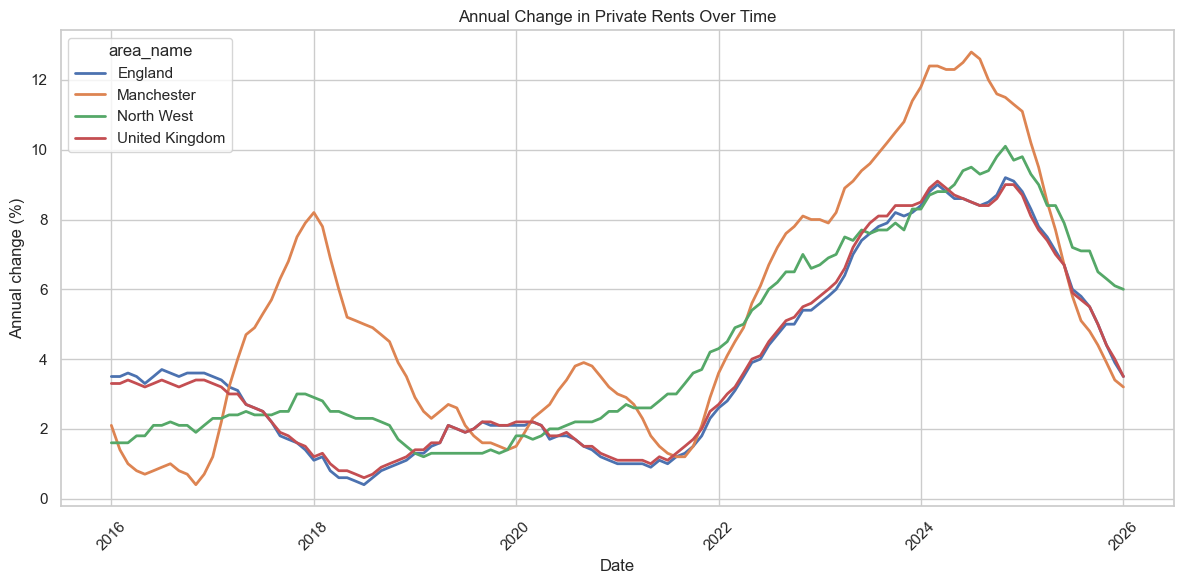

In [10]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="date", y="annual_change", hue="area_name", linewidth=2)

plt.title("Annual Change in Private Rents Over Time")
plt.xlabel("Date")
plt.ylabel("Annual change (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join('figures', 'annual_rent_change_over_time.png'), dpi=300, bbox_inches='tight')
plt.show()

This line chart is the main visual in the project. It shows that annual rent-change rates increased strongly during the later part of the period, especially during 2023–2025. Manchester stands out because its annual percentage change rose higher than the wider benchmark areas during that surge.

In [11]:
# Summary statistics by area help quantify the patterns seen in the line chart
group_stats = (
    df.groupby("area_name")["annual_change"]
    .agg(["mean", "median", "std", "min", "max"])
    .round(2)
    .sort_values("mean", ascending=False)
)

print(group_stats)

                mean  median   std  min   max
area_name                                    
Manchester      5.29     4.5  3.61  0.4  12.8
North West      4.35     2.7  2.84  1.2  10.1
United Kingdom  3.85     3.2  2.69  0.6   9.1
England         3.81     3.2  2.70  0.4   9.2


The summary statistics show that:

- **Manchester has the highest mean annual rent change** in the dataset.
- **Manchester also has the highest standard deviation**, which indicates the greatest volatility.
- England and the United Kingdom have very similar overall distributions, which is expected because the UK-wide series is smoother and more aggregated.

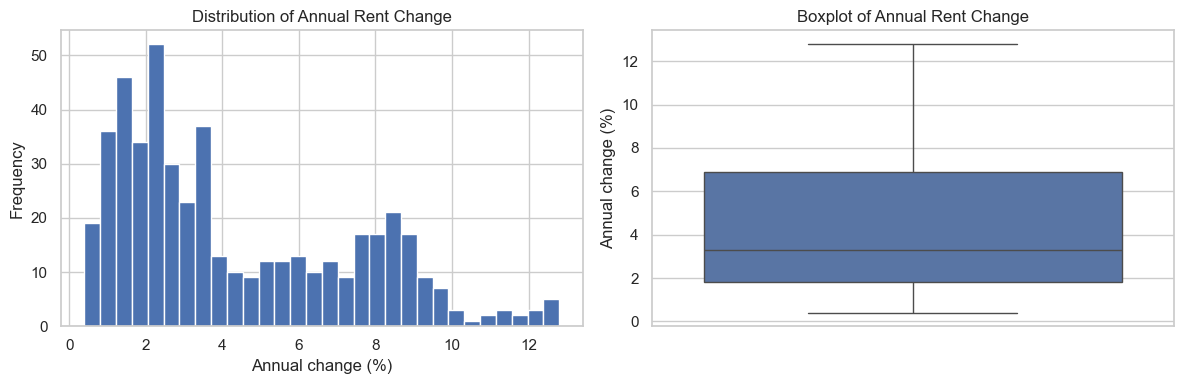

Skewness of annual_change: 0.77


In [12]:
# Distribution analysis for the main variable
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["annual_change"], bins=30)
axes[0].set_title("Distribution of Annual Rent Change")
axes[0].set_xlabel("Annual change (%)")
axes[0].set_ylabel("Frequency")

sns.boxplot(data=df, y="annual_change", ax=axes[1])
axes[1].set_title("Boxplot of Annual Rent Change")
axes[1].set_ylabel("Annual change (%)")

plt.tight_layout()
plt.savefig(os.path.join('figures', 'annual_change_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()

print("Skewness of annual_change:", round(df["annual_change"].skew(), 2))

The overall distribution is moderately **right-skewed**, which means larger positive rent-change values occur more often than equally large negative values. The boxplot also shows a long upper tail rather than a symmetric spread around the centre.

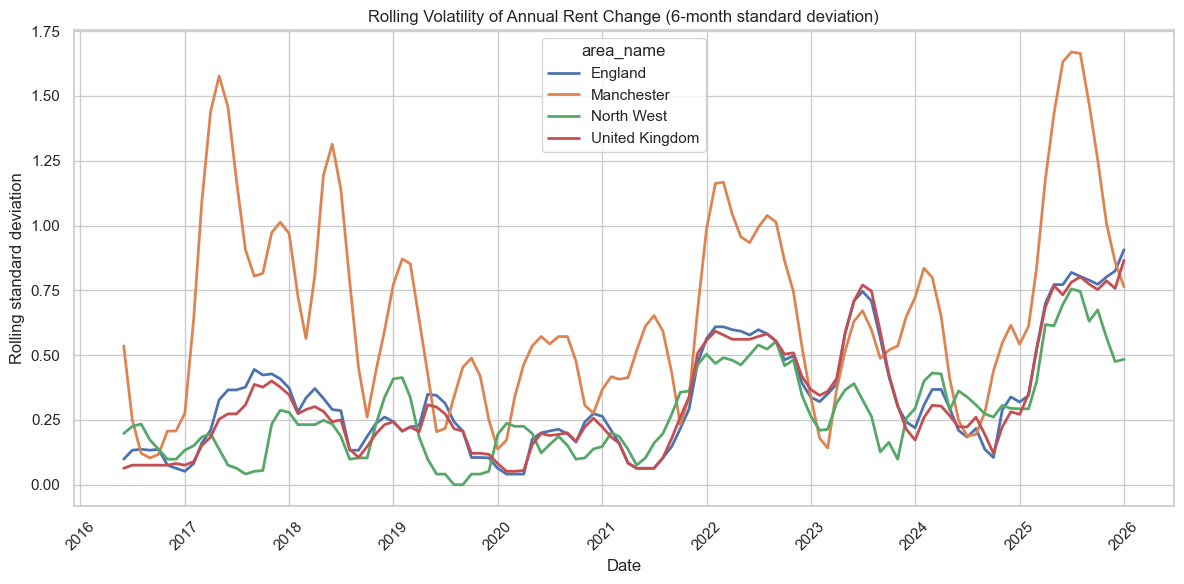

Average rolling volatility by area:
area_name
England           0.33
Manchester        0.67
North West        0.27
United Kingdom    0.32
Name: rolling_std_6m, dtype: float64


In [13]:
# Rolling volatility: a 6-month rolling standard deviation
df["rolling_std_6m"] = (
    df.groupby("area_name")["annual_change"]
    .transform(lambda x: x.rolling(6).std())
)

plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="date", y="rolling_std_6m", hue="area_name", linewidth=2)

plt.title("Rolling Volatility of Annual Rent Change (6-month standard deviation)")
plt.xlabel("Date")
plt.ylabel("Rolling standard deviation")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join('figures', 'rolling_volatility_6m.png'), dpi=300, bbox_inches='tight')
plt.show()

rolling_summary = df.groupby("area_name")["rolling_std_6m"].mean().round(2)
print("Average rolling volatility by area:")
print(rolling_summary)

Rolling volatility makes the contrast even clearer: Manchester has the highest short-run instability, while England and the UK remain smoother over time. In other words, Manchester is not only showing higher average annual rent-change rates, but also sharper movement from month to month.

Latest month in dataset: Jan 2026
        area_name       date  annual_change  rolling_std_6m
0      North West 2026-01-01            6.0        0.483391
1         England 2026-01-01            3.5        0.906458
2  United Kingdom 2026-01-01            3.5        0.865833
3      Manchester 2026-01-01            3.2        0.763326


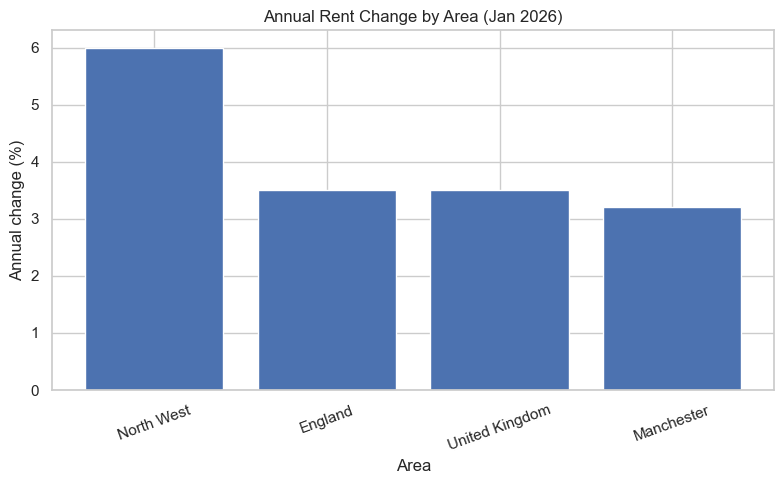

In [14]:
# Latest month comparison
latest_date = df["date"].max()
latest_data = df[df["date"] == latest_date].sort_values("annual_change", ascending=False).reset_index(drop=True)

print("Latest month in dataset:", latest_date.strftime("%b %Y"))
print(latest_data)

plt.figure(figsize=(8, 5))
plt.bar(latest_data["area_name"], latest_data["annual_change"])
plt.title(f"Annual Rent Change by Area ({latest_date.strftime('%b %Y')})")
plt.xlabel("Area")
plt.ylabel("Annual change (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(os.path.join('figures', 'latest_month_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

By the latest month in the dataset (**January 2026**), North West has the highest annual rent change at **6.0%**, while Manchester is lower at **3.2%**. This matters because it shows that Manchester was extremely strong over much of the period, but it was not the strongest area in the final month.

In [15]:
# Identify peak and trough months for each area
max_points = df.loc[
    df.groupby("area_name")["annual_change"].idxmax(),
    ["area_name", "date", "annual_change"]
].sort_values("area_name").reset_index(drop=True)

min_points = df.loc[
    df.groupby("area_name")["annual_change"].idxmin(),
    ["area_name", "date", "annual_change"]
].sort_values("area_name").reset_index(drop=True)

print("=== HIGHEST POINT BY AREA ===")
print(max_points)

print("\n=== LOWEST POINT BY AREA ===")
print(min_points)

=== HIGHEST POINT BY AREA ===
        area_name       date  annual_change
0         England 2024-11-01            9.2
1      Manchester 2024-07-01           12.8
2      North West 2024-11-01           10.1
3  United Kingdom 2024-03-01            9.1

=== LOWEST POINT BY AREA ===
        area_name       date  annual_change
0         England 2018-07-01            0.4
1      Manchester 2016-11-01            0.4
2      North West 2019-02-01            1.2
3  United Kingdom 2018-07-01            0.6


The peak table shows that Manchester reached the highest single value in the whole comparison set: **12.8% in July 2024**. The lowest values across the four series were all much smaller in magnitude, which reinforces the idea that the main story here is about periods of unusually strong rent growth rather than severe declines.

### 3.2 Snapshot analysis: rent change by bedroom type

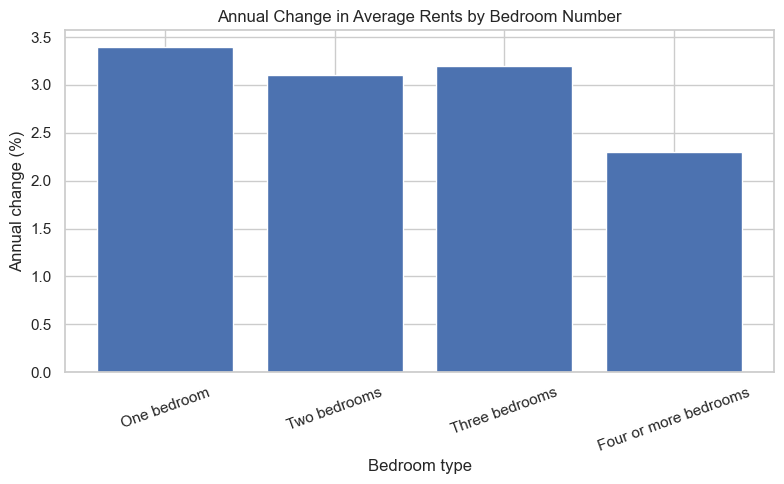

            bedroom_type  annual_change
0            One bedroom            3.4
2         Three bedrooms            3.2
1           Two bedrooms            3.1
3  Four or more bedrooms            2.3


In [16]:
plt.figure(figsize=(8, 5))
plt.bar(df_bedroom["bedroom_type"], df_bedroom["annual_change"])

plt.title("Annual Change in Average Rents by Bedroom Number")
plt.xlabel("Bedroom type")
plt.ylabel("Annual change (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(os.path.join('figures', 'bedroom_type_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

print(df_bedroom.sort_values("annual_change", ascending=False))

The bedroom comparison shows a modest but clear ranking:

- **One-bedroom properties** have the highest annual change (**3.4%**)
- **Three-bedroom properties** follow closely (**3.2%**)
- **Two-bedroom properties** are slightly lower (**3.1%**)
- **Four or more bedrooms** have the lowest annual change (**2.3%**)

This suggests that smaller properties were seeing stronger recent rental growth than the largest homes.

### 3.3 Snapshot analysis: average rent level comparison

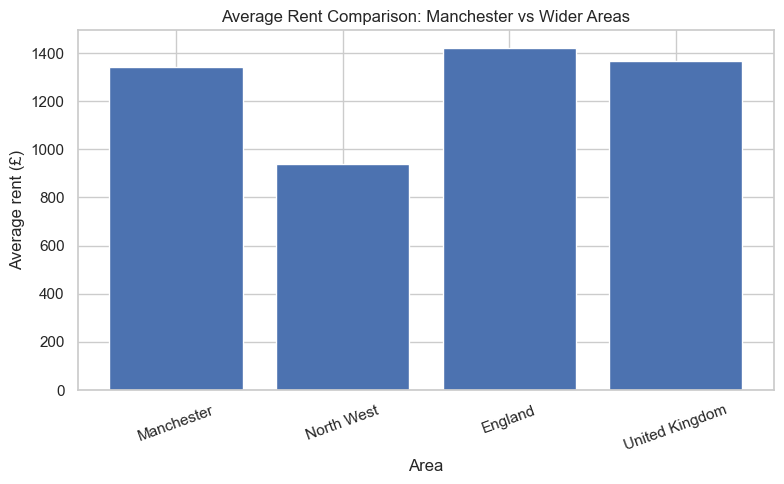

        area_name  average_rent
2         England        1423.0
3  United Kingdom        1367.0
0      Manchester        1343.0
1      North West         941.0


In [17]:
plt.figure(figsize=(8, 5))
plt.bar(df_level["area_name"], df_level["average_rent"])

plt.title("Average Rent Comparison: Manchester vs Wider Areas")
plt.xlabel("Area")
plt.ylabel("Average rent (£)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(os.path.join('figures', 'average_rent_level_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

print(df_level.sort_values("average_rent", ascending=False))

The average rent comparison adds useful context to the trend analysis:

- **England** has the highest average rent (£1423)
- **United Kingdom** follows (£1367)
- **Manchester** is next (£1343)
- **North West** is lowest (£941)

So Manchester's rent level is **well above the North West benchmark**, but still **below England overall**. This is an important nuance: Manchester is not the most expensive area in absolute terms, yet its rent growth over time has been particularly strong.

## 4. Key Findings

In [18]:
key_findings = {
    "Date range": f"{df['date'].min().strftime('%b %Y')} to {df['date'].max().strftime('%b %Y')}",
    "Observations per area": int(df.groupby('area_name')['date'].count().iloc[0]),
    "Manchester mean annual change": round(group_stats.loc['Manchester', 'mean'], 2),
    "Manchester volatility (std)": round(group_stats.loc['Manchester', 'std'], 2),
    "Manchester peak": f"{max_points.loc[max_points['area_name']=='Manchester', 'annual_change'].iloc[0]}% in {max_points.loc[max_points['area_name']=='Manchester', 'date'].iloc[0].strftime('%b %Y')}",
    "Latest month Manchester": f"{latest_data.loc[latest_data['area_name']=='Manchester', 'annual_change'].iloc[0]}% in {latest_date.strftime('%b %Y')}",
    "Highest bedroom-type change": f"{df_bedroom.sort_values('annual_change', ascending=False).iloc[0]['bedroom_type']} ({df_bedroom['annual_change'].max()}%)",
    "Manchester average rent": f"£{int(df_level.loc[df_level['area_name']=='Manchester', 'average_rent'].iloc[0])}"
}

for key, value in key_findings.items():
    print(f"- {key}: {value}")

- Date range: Jan 2016 to Jan 2026
- Observations per area: 121
- Manchester mean annual change: 5.29
- Manchester volatility (std): 3.61
- Manchester peak: 12.8% in Jul 2024
- Latest month Manchester: 3.2% in Jan 2026
- Highest bedroom-type change: One bedroom (3.4%)
- Manchester average rent: £1343


### Interpretation of the findings

Taken together, the three datasets tell a consistent story:

1. **Manchester experienced stronger annual rent growth than the wider benchmarks for much of the period.**
2. **Manchester was also the most volatile series**, which means rent growth was less stable there than in England or the UK overall.
3. **Smaller properties showed stronger recent growth than larger ones**, especially one-bedroom homes.
4. **Manchester's average rent level is high relative to the North West**, even though it remains below the England-wide average.

This combination matters because it shows that Manchester is a market with both **high recent growth pressure** and **comparatively high price levels within its region**, but it is not identical to the national picture.

## 5. Limitations

This is a small exploratory project, so the findings should be read as descriptive rather than causal.

Some limitations are:

- The main dataset shows **annual percentage change**, not the underlying monthly rent price for every area.
- The bedroom and average-rent datasets are snapshots for January 2026, so they add context but are not full time series.
- The analysis compares selected areas only; it does not include every local authority in the UK.
- The project does not test what caused the changes. Possible drivers such as supply, demand, wages, student population, or migration would need additional data.

## 6. Conclusion

This exploratory data analysis used three related datasets to examine rent patterns in Manchester. The main time-series dataset showed that Manchester generally had stronger annual rent growth than North West, England, and the United Kingdom, with a particularly strong surge in 2024. It also showed greater volatility than the broader benchmarks.

The bedroom-type comparison added further detail by suggesting that smaller properties, especially one-bedroom homes, were experiencing the strongest recent rent increases. The average-rent comparison showed that Manchester's rent level was clearly above the North West benchmark, although still below the England-wide average.

Overall, the project suggests that Manchester is a fast-growing and comparatively expensive rental market within its region, with notable pressure in smaller property segments.